<a href="https://colab.research.google.com/github/Merllin23/AccidentSeverityPrediction/blob/main/Prueba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports, carga y limpieza

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

datasets

In [2]:
# Cargar dataset SUTRAN

sutran = pd.read_csv(
    "/content/drive/MyDrive/UTP/innovacion/Accidentes de tránsito en carreteras-2020-2021-Sutran.csv",
    sep=";",
    encoding="latin1"
)


# Cargar dataset SENAMHI

senamhi = pd.read_csv(
    "/content/drive/MyDrive/UTP/innovacion/Variables Meteorologicas de las Estaciones automáticas de intercambio internacional - [Servicio Nacional de Meteorología e Hidrología del Perú - SENAMHI]_0.csv",
    encoding="latin1"
)

print("SUTRAN:", sutran.shape)
print("SENAMHI:", senamhi.shape)

SUTRAN: (8155, 9)
SENAMHI: (416273, 16)


In [3]:
# Convertir fechas a formato fecha

sutran["FECHA"] = pd.to_datetime(
    sutran["FECHA"].astype(str),
    format="%Y%m%d"
)

senamhi["FECHA"] = pd.to_datetime(
    senamhi["FECHA"].astype(str),
    format="%Y%m%d"
)

In [4]:
sutran["HORA_LIMPIA"] = (
    sutran["HORA"]
    .replace("N.I.", "00:00")
)

sutran["HORA_NUM"] = (
    sutran["HORA_LIMPIA"]
    .str[:2]
    .astype(int)
)

In [5]:
def convertir_hora(valor):

    valor = int(valor)

    if valor == 0:
        return 0

    return valor // 10000


senamhi["HORA_NUM"] = senamhi["HORA"].apply(
    convertir_hora
)

In [6]:
sutran["FALLECIDOS"] = pd.to_numeric(
    sutran["FALLECIDOS"],
    errors="coerce"
).fillna(0)

sutran["HERIDOS"] = pd.to_numeric(
    sutran["HERIDOS"],
    errors="coerce"
).fillna(0)

In [7]:
def gravedad(fila):

    if fila["FALLECIDOS"] > 0:
        return "ALTO"

    elif fila["HERIDOS"] > 2:
        return "MEDIO"

    else:
        return "BAJO"


sutran["GRAVEDAD"] = sutran.apply(
    gravedad,
    axis=1
)

In [8]:
sutran["GRAVEDAD"].value_counts()

,count
GRAVEDAD,
BAJO,6233
MEDIO,969
ALTO,953


In [9]:
variables_clima = [
    "FECHA",
    "DEPARTAMENTO",
    "HORA_NUM",
    "TEMP",
    "HR",
    "PP",
    "ALTITUD"
]

In [10]:
senamhi_modelo = (
    senamhi[variables_clima]
    .groupby(
        [
            "FECHA",
            "DEPARTAMENTO",
            "HORA_NUM"
        ],
        as_index=False
    )
    .agg({
        "TEMP":"mean",
        "HR":"mean",
        "PP":"mean",
        "ALTITUD":"mean"
    })
)

In [11]:
dataset = pd.merge(
    sutran,
    senamhi_modelo,
    on=[
        "FECHA",
        "DEPARTAMENTO",
        "HORA_NUM"
    ],
    how="left"
)

In [12]:
variables_clima = [
    "TEMP",
    "HR",
    "PP",
    "ALTITUD"
]

In [13]:
for columna in variables_clima:

    dataset[columna] = (
        dataset
        .groupby("DEPARTAMENTO")[columna]
        .transform(
            lambda x: x.fillna(
                x.median()
            )
        )
    )

In [14]:
for columna in variables_clima:

    dataset[columna] = dataset[columna].fillna(
        dataset[columna].median()
    )

In [15]:
dataset.isnull().sum()

,0
FECHA_CORTE,0
FECHA,0
HORA,0
DEPARTAMENTO,0
CODIGO_VÍA,0
KILOMETRO,0
MODALIDAD,0
FALLECIDOS,0
HERIDOS,0
HORA_LIMPIA,0


In [16]:
dataset["KILOMETRO"] = pd.to_numeric(
    dataset["KILOMETRO"],
    errors="coerce"
)

dataset["KILOMETRO"] = dataset["KILOMETRO"].fillna(
    dataset["KILOMETRO"].median()
)

Entrenamiento y prueba

In [17]:
dataset["AÑO"] = dataset["FECHA"].dt.year

dataset["MES"] = dataset["FECHA"].dt.month

dataset["DIA"] = dataset["FECHA"].dt.day

dataset["DIA_SEMANA"] = dataset["FECHA"].dt.dayofweek

In [18]:
dataset["FIN_SEMANA"] = (
    dataset["DIA_SEMANA"] >= 5
).astype(int)

In [19]:
dataset["TRIMESTRE"] = dataset["FECHA"].dt.quarter

In [20]:
def periodo_dia(hora):

    if 0 <= hora <= 5:
        return "MADRUGADA"

    elif hora <= 11:
        return "MAÑANA"

    elif hora <= 17:
        return "TARDE"

    else:
        return "NOCHE"


dataset["PERIODO"] = dataset["HORA_NUM"].apply(
    periodo_dia
)

In [21]:
def estacion(mes):

    if mes in [12,1,2]:
        return "VERANO"

    elif mes in [3,4,5]:
        return "OTOÑO"

    elif mes in [6,7,8]:
        return "INVIERNO"

    else:
        return "PRIMAVERA"


dataset["ESTACION"] = dataset["MES"].apply(
    estacion
)

In [22]:
dataset["LLUVIA"] = (
    dataset["PP"] > 0
).astype(int)

In [23]:
dataset["HUMEDAD_ALTA"] = (
    dataset["HR"] >= 90
).astype(int)

In [24]:
dataset["TEMP_BAJA"] = (
    dataset["TEMP"] < 10
).astype(int)

In [25]:
dataset["TEMP_ALTA"] = (
    dataset["TEMP"] > 25
).astype(int)

In [26]:
dataset["ZONA_ALTA"] = (
    dataset["ALTITUD"] > 3000
).astype(int)

In [27]:
dataset.head()

,FECHA_CORTE,FECHA,HORA,DEPARTAMENTO,CODIGO_VÍA,KILOMETRO,MODALIDAD,FALLECIDOS,HERIDOS,HORA_LIMPIA,...,DIA_SEMANA,FIN_SEMANA,TRIMESTRE,PERIODO,ESTACION,LLUVIA,HUMEDAD_ALTA,TEMP_BAJA,TEMP_ALTA,ZONA_ALTA
0,20211222,2020-01-01,05:40,LIMA,PE-1S,24.0,DESPISTE,0.0,0.0,05:40,...,2,0,1,MADRUGADA,VERANO,0,1,1,0,1
1,20211222,2020-01-01,16:30,CAJAMARCA,PE-3N,74.0,DESPISTE,0.0,0.0,16:30,...,2,0,1,TARDE,VERANO,0,0,1,0,1
2,20211222,2020-01-01,07:45,PASCO,PE-3N,103.0,DESPISTE,0.0,1.0,07:45,...,2,0,1,MAÑANA,VERANO,0,0,1,0,1
3,20211222,2020-01-01,18:30,CAJAMARCA,PE-08,111.0,DESPISTE,0.0,2.0,18:30,...,2,0,1,NOCHE,VERANO,0,0,1,0,1
4,20211222,2020-01-01,18:40,LIMA,PE-1N,174.0,DESPISTE,0.0,5.0,18:40,...,2,0,1,NOCHE,VERANO,0,1,0,0,1


In [28]:
#eliminar columnas que no usaremos
dataset_modelo = dataset.drop(
    columns=[
        "FECHA_CORTE",
        "FECHA",
        "HORA",
        "HORA_LIMPIA",
        "FALLECIDOS",
        "HERIDOS"
    ]
)

In [29]:
dataset_modelo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8155 entries, 0 to 8154
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   DEPARTAMENTO  8155 non-null   object 
 1   CODIGO_VÍA    8155 non-null   object 
 2   KILOMETRO     8155 non-null   float64
 3   MODALIDAD     8155 non-null   object 
 4   HORA_NUM      8155 non-null   int64  
 5   GRAVEDAD      8155 non-null   object 
 6   TEMP          8155 non-null   float64
 7   HR            8155 non-null   float64
 8   PP            8155 non-null   float64
 9   ALTITUD       8155 non-null   float64
 10  AÑO           8155 non-null   int32  
 11  MES           8155 non-null   int32  
 12  DIA           8155 non-null   int32  
 13  DIA_SEMANA    8155 non-null   int32  
 14  FIN_SEMANA    8155 non-null   int64  
 15  TRIMESTRE     8155 non-null   int32  
 16  PERIODO       8155 non-null   object 
 17  ESTACION      8155 non-null   object 
 18  LLUVIA        8155 non-null 

In [30]:
dataset_modelo.isnull().sum()

,0
DEPARTAMENTO,0
CODIGO_VÍA,0
KILOMETRO,0
MODALIDAD,0
HORA_NUM,0
GRAVEDAD,0
TEMP,0
HR,0
PP,0
ALTITUD,0


Machine Learning


In [31]:
dataset_ml = dataset_modelo.copy()

dataset_ml.head()

,DEPARTAMENTO,CODIGO_VÍA,KILOMETRO,MODALIDAD,HORA_NUM,GRAVEDAD,TEMP,HR,PP,ALTITUD,...,DIA_SEMANA,FIN_SEMANA,TRIMESTRE,PERIODO,ESTACION,LLUVIA,HUMEDAD_ALTA,TEMP_BAJA,TEMP_ALTA,ZONA_ALTA
0,LIMA,PE-1S,24.0,DESPISTE,5,BAJO,8.55,98.5,0.0,3130.5,...,2,0,1,MADRUGADA,VERANO,0,1,1,0,1
1,CAJAMARCA,PE-3N,74.0,DESPISTE,16,BAJO,9.85,64.0,0.0,3130.5,...,2,0,1,TARDE,VERANO,0,0,1,0,1
2,PASCO,PE-3N,103.0,DESPISTE,7,BAJO,9.85,64.0,0.0,3130.5,...,2,0,1,MAÑANA,VERANO,0,0,1,0,1
3,CAJAMARCA,PE-08,111.0,DESPISTE,18,BAJO,9.85,64.0,0.0,3130.5,...,2,0,1,NOCHE,VERANO,0,0,1,0,1
4,LIMA,PE-1N,174.0,DESPISTE,18,MEDIO,10.85,93.0,0.0,3130.5,...,2,0,1,NOCHE,VERANO,0,1,0,0,1


In [32]:
X = dataset_ml.drop(
    columns=["GRAVEDAD"]
)

y = dataset_ml["GRAVEDAD"]

In [33]:
X = pd.get_dummies(
    X,
    columns=[
        "DEPARTAMENTO",
        "CODIGO_VÍA",
        "MODALIDAD",
        "PERIODO",
        "ESTACION"
    ],
    drop_first=True
)

In [34]:
X.head()

,KILOMETRO,HORA_NUM,TEMP,HR,PP,ALTITUD,AÑO,MES,DIA,DIA_SEMANA,...,MODALIDAD_DESPISTE,MODALIDAD_ESPECIAL,MODALIDAD_N.I.,MODALIDAD_VOLCADURA,PERIODO_MAÑANA,PERIODO_NOCHE,PERIODO_TARDE,ESTACION_OTOÑO,ESTACION_PRIMAVERA,ESTACION_VERANO
0,24.0,5,8.55,98.5,0.0,3130.5,2020,1,1,2,...,True,False,False,False,False,False,False,False,False,True
1,74.0,16,9.85,64.0,0.0,3130.5,2020,1,1,2,...,True,False,False,False,False,False,True,False,False,True
2,103.0,7,9.85,64.0,0.0,3130.5,2020,1,1,2,...,True,False,False,False,True,False,False,False,False,True
3,111.0,18,9.85,64.0,0.0,3130.5,2020,1,1,2,...,True,False,False,False,False,True,False,False,False,True
4,174.0,18,10.85,93.0,0.0,3130.5,2020,1,1,2,...,True,False,False,False,False,True,False,False,False,True


In [35]:
encoder_y = LabelEncoder()

y = encoder_y.fit_transform(y)

In [36]:
encoder_y.classes_

array(['ALTO', 'BAJO', 'MEDIO'], dtype=object)

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [38]:
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (6524, 230)
Prueba: (1631, 230)


In [39]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [40]:
pd.Series(y_train_smote).value_counts()

,count
1,4987
0,4987
2,4987


Random Forest

In [41]:
modelo_rf = RandomForestClassifier(

    n_estimators=600,

    max_depth=15,

    min_samples_split=5,

    min_samples_leaf=2,

    class_weight="balanced",

    random_state=42,

    n_jobs=-1
)

In [42]:
modelo_rf.fit(
    X_train_smote,
    y_train_smote
)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=600, n_jobs=-1, random_state=42)

In [43]:
pred_rf = modelo_rf.predict(
    X_test
)

In [44]:
print(
    accuracy_score(
        y_test,
        pred_rf
    )
)

print(
    classification_report(
        y_test,
        pred_rf,
        target_names=encoder_y.classes_
    )
)

0.7185775597792765
              precision    recall  f1-score   support

        ALTO       0.20      0.10      0.13       191
        BAJO       0.77      0.92      0.84      1246
       MEDIO       0.12      0.03      0.04       194

    accuracy                           0.72      1631
   macro avg       0.36      0.35      0.34      1631
weighted avg       0.62      0.72      0.66      1631



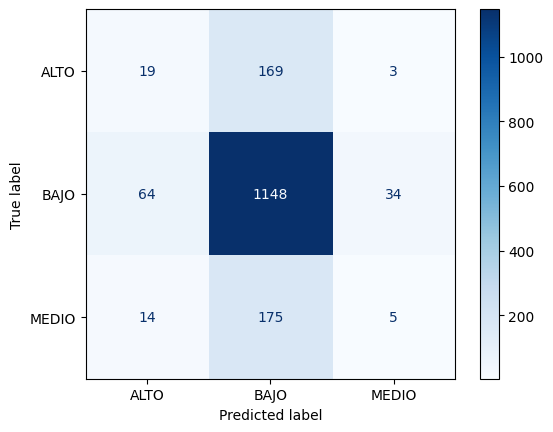

In [45]:
ConfusionMatrixDisplay.from_predictions(

    y_test,

    pred_rf,

    display_labels=encoder_y.classes_,

    cmap="Blues"

)

plt.show()

In [46]:
importancias = pd.DataFrame({

    "Variable": X.columns,

    "Importancia": modelo_rf.feature_importances_

})

importancias = importancias.sort_values(

    by="Importancia",

    ascending=False
)

importancias.head(20)

,Variable,Importancia
219,MODALIDAD_CHOQUE,0.078278
0,KILOMETRO,0.067883
1,HORA_NUM,0.050171
7,MES,0.049470
8,DIA,0.044586
6,AÑO,0.041725
220,MODALIDAD_DESPISTE,0.040004
11,TRIMESTRE,0.037148
9,DIA_SEMANA,0.035659
226,PERIODO_TARDE,0.033758


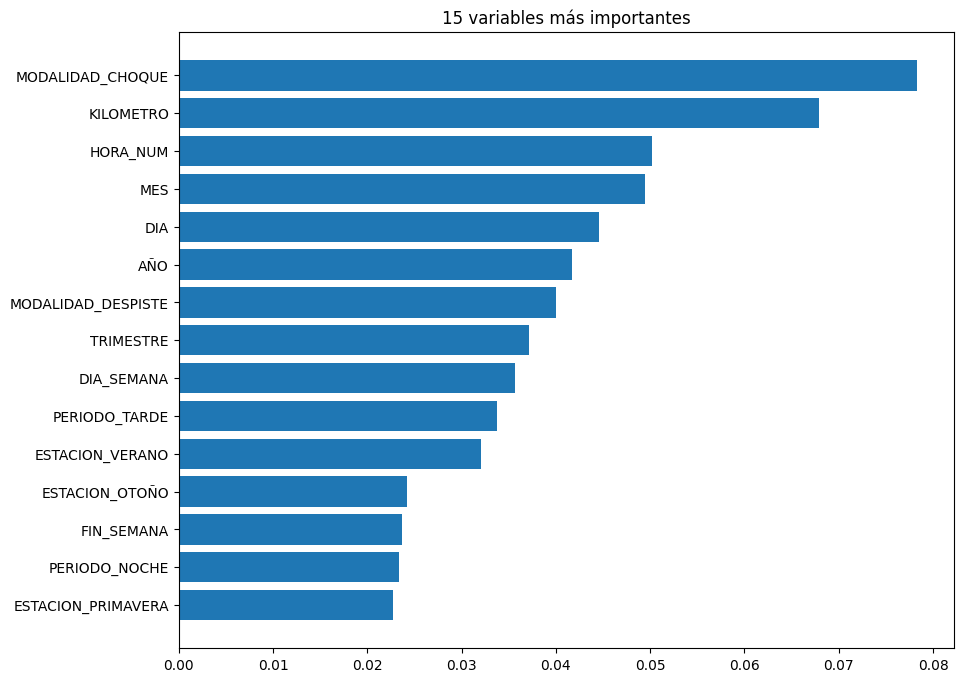

In [47]:
#grafico
plt.figure(figsize=(10,8))

plt.barh(

    importancias["Variable"][:15],

    importancias["Importancia"][:15]

)

plt.gca().invert_yaxis()

plt.title("15 variables más importantes")

plt.show()

XGBoost

In [48]:
modelo_xgb = XGBClassifier(

    n_estimators=500,

    learning_rate=0.03,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    eval_metric="mlogloss"
)

modelo_xgb.fit(

    X_train_smote,

    y_train_smote
)

pred_xgb = modelo_xgb.predict(
    X_test
)

print(
    accuracy_score(
        y_test,
        pred_xgb
    )
)

print(
    classification_report(
        y_test,
        pred_xgb,
        target_names=encoder_y.classes_
    )
)

0.7473942366646229
              precision    recall  f1-score   support

        ALTO       0.29      0.09      0.14       191
        BAJO       0.77      0.96      0.86      1246
       MEDIO       0.14      0.02      0.03       194

    accuracy                           0.75      1631
   macro avg       0.40      0.36      0.34      1631
weighted avg       0.64      0.75      0.68      1631



Upgrade

In [49]:
dataset_ml = dataset_modelo.copy()

In [50]:
#dataset_ml = dataset_ml.drop(
 #   columns=[
  #      "FECHA_CORTE",
   #     "FECHA",
    ##   "HORA_LIMPIA",
      #  "FALLECIDOS",
       # "HERIDOS"
 #   ]
#)#

In [51]:
dataset_ml.info()

dataset_ml.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8155 entries, 0 to 8154
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   DEPARTAMENTO  8155 non-null   object 
 1   CODIGO_VÍA    8155 non-null   object 
 2   KILOMETRO     8155 non-null   float64
 3   MODALIDAD     8155 non-null   object 
 4   HORA_NUM      8155 non-null   int64  
 5   GRAVEDAD      8155 non-null   object 
 6   TEMP          8155 non-null   float64
 7   HR            8155 non-null   float64
 8   PP            8155 non-null   float64
 9   ALTITUD       8155 non-null   float64
 10  AÑO           8155 non-null   int32  
 11  MES           8155 non-null   int32  
 12  DIA           8155 non-null   int32  
 13  DIA_SEMANA    8155 non-null   int32  
 14  FIN_SEMANA    8155 non-null   int64  
 15  TRIMESTRE     8155 non-null   int32  
 16  PERIODO       8155 non-null   object 
 17  ESTACION      8155 non-null   object 
 18  LLUVIA        8155 non-null 

,DEPARTAMENTO,CODIGO_VÍA,KILOMETRO,MODALIDAD,HORA_NUM,GRAVEDAD,TEMP,HR,PP,ALTITUD,...,DIA_SEMANA,FIN_SEMANA,TRIMESTRE,PERIODO,ESTACION,LLUVIA,HUMEDAD_ALTA,TEMP_BAJA,TEMP_ALTA,ZONA_ALTA
0,LIMA,PE-1S,24.0,DESPISTE,5,BAJO,8.55,98.5,0.0,3130.5,...,2,0,1,MADRUGADA,VERANO,0,1,1,0,1
1,CAJAMARCA,PE-3N,74.0,DESPISTE,16,BAJO,9.85,64.0,0.0,3130.5,...,2,0,1,TARDE,VERANO,0,0,1,0,1
2,PASCO,PE-3N,103.0,DESPISTE,7,BAJO,9.85,64.0,0.0,3130.5,...,2,0,1,MAÑANA,VERANO,0,0,1,0,1
3,CAJAMARCA,PE-08,111.0,DESPISTE,18,BAJO,9.85,64.0,0.0,3130.5,...,2,0,1,NOCHE,VERANO,0,0,1,0,1
4,LIMA,PE-1N,174.0,DESPISTE,18,MEDIO,10.85,93.0,0.0,3130.5,...,2,0,1,NOCHE,VERANO,0,1,0,0,1


In [52]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

columnas_categoricas = [
    "DEPARTAMENTO",
    "CODIGO_VÍA",
    "MODALIDAD",
    "GRAVEDAD"
]

for columna in columnas_categoricas:

    encoder = LabelEncoder()

    dataset_ml[columna] = encoder.fit_transform(
        dataset_ml[columna]
    )

    encoders[columna] = encoder

In [53]:
dataset_ml.head()

,DEPARTAMENTO,CODIGO_VÍA,KILOMETRO,MODALIDAD,HORA_NUM,GRAVEDAD,TEMP,HR,PP,ALTITUD,...,DIA_SEMANA,FIN_SEMANA,TRIMESTRE,PERIODO,ESTACION,LLUVIA,HUMEDAD_ALTA,TEMP_BAJA,TEMP_ALTA,ZONA_ALTA
0,16,94,24.0,2,5,1,8.55,98.5,0.0,3130.5,...,2,0,1,MADRUGADA,VERANO,0,1,1,0,1
1,6,139,74.0,2,16,1,9.85,64.0,0.0,3130.5,...,2,0,1,TARDE,VERANO,0,0,1,0,1
2,21,139,103.0,2,7,1,9.85,64.0,0.0,3130.5,...,2,0,1,MAÑANA,VERANO,0,0,1,0,1
3,6,62,111.0,2,18,1,9.85,64.0,0.0,3130.5,...,2,0,1,NOCHE,VERANO,0,0,1,0,1
4,16,84,174.0,2,18,2,10.85,93.0,0.0,3130.5,...,2,0,1,NOCHE,VERANO,0,1,0,0,1


In [54]:
dataset_ml["GRAVEDAD"].value_counts()

,count
GRAVEDAD,
1,6233
2,969
0,953


In [55]:
X = dataset_ml.drop(
    columns="GRAVEDAD"
)

y = dataset_ml["GRAVEDAD"]

In [56]:
print("Variables:", X.shape)
print("Objetivo:", y.shape)

Variables: (8155, 22)
Objetivo: (8155,)


In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [58]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(6524, 22)
(1631, 22)
(6524,)
(1631,)


In [59]:
columnas_numericas = [
    "KILOMETRO",
    "TEMP",
    "HR",
    "PP",
    "ALTITUD"
]

In [60]:
X_train_scaled = X_train.copy()

X_test_scaled = X_test.copy()

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled[columnas_numericas] = scaler.fit_transform(
    X_train[columnas_numericas]
)

X_test_scaled[columnas_numericas] = scaler.transform(
    X_test[columnas_numericas]
)

Upgrade de ML

Decision Tree

In [62]:
modelo_dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5
)

# One-hot encode the 'PERIODO' and 'ESTACION' columns
X_train_processed = pd.get_dummies(X_train, columns=["PERIODO", "ESTACION"], drop_first=True)
X_test_processed = pd.get_dummies(X_test, columns=["PERIODO", "ESTACION"], drop_first=True)

modelo_dt.fit(
    X_train_processed,
    y_train
)

pred_dt = modelo_dt.predict(X_test_processed)

In [63]:
print("===== DECISION TREE =====")

print(
    "Accuracy:",
    accuracy_score(y_test, pred_dt)
)

print()

print(
    classification_report(
        y_test,
        pred_dt
    )
)

===== DECISION TREE =====
Accuracy: 0.3911710606989577

              precision    recall  f1-score   support

           0       0.18      0.42      0.25       191
           1       0.79      0.39      0.53      1246
           2       0.12      0.35      0.18       194

    accuracy                           0.39      1631
   macro avg       0.36      0.39      0.32      1631
weighted avg       0.64      0.39      0.45      1631



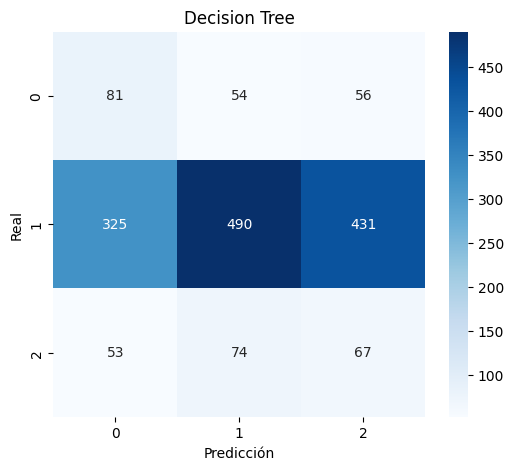

In [64]:
cm = confusion_matrix(
    y_test,
    pred_dt
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Decision Tree")

plt.show()

In [65]:
importancias = pd.DataFrame({

    "Variable": X_train_processed.columns,

    "Importancia": modelo_dt.feature_importances_

})

importancias = importancias.sort_values(
    "Importancia",
    ascending=False
)

display(importancias)

,Variable,Importancia
2,KILOMETRO,0.203196
11,DIA,0.132805
3,MODALIDAD,0.123849
1,CODIGO_VÍA,0.108456
4,HORA_NUM,0.099760
0,DEPARTAMENTO,0.057913
5,TEMP,0.052768
12,DIA_SEMANA,0.046018
6,HR,0.043633
10,MES,0.040360


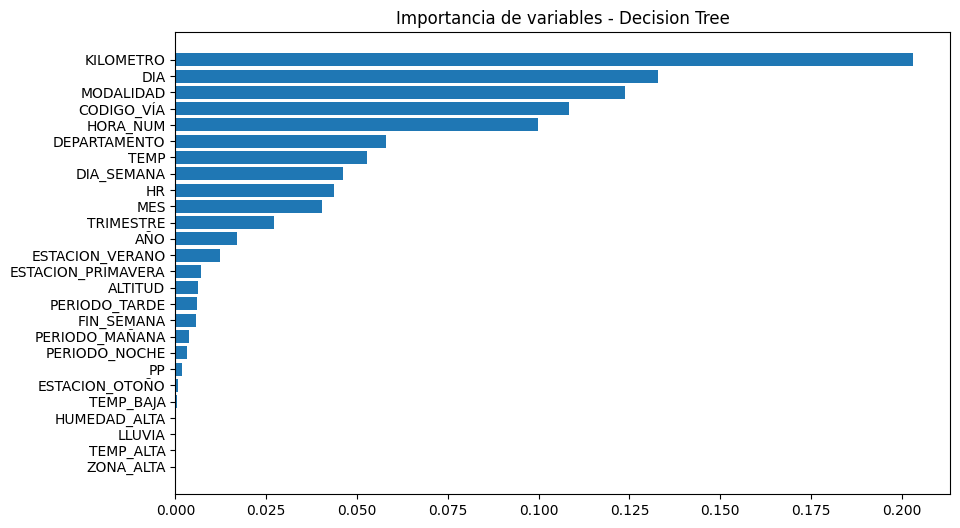

In [66]:
plt.figure(figsize=(10,6))

plt.barh(
    importancias["Variable"],
    importancias["Importancia"]
)

plt.gca().invert_yaxis()

plt.title("Importancia de variables - Decision Tree")

plt.show()

Random Forest

In [67]:
modelo_rf = RandomForestClassifier(

    n_estimators=500,

    random_state=42,

    class_weight="balanced",

    max_depth=None,

    min_samples_split=5,

    min_samples_leaf=2,

    n_jobs=-1

)

# Apply one-hot encoding to categorical string columns before fitting the model
X_train_encoded = pd.get_dummies(X_train, columns=["PERIODO", "ESTACION"], drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=["PERIODO", "ESTACION"], drop_first=True)

modelo_rf.fit(
    X_train_encoded,
    y_train
)

pred_rf = modelo_rf.predict(
    X_test_encoded
)

In [68]:
print("===== RANDOM FOREST =====")

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred_rf
    )
)

print()

print(
    classification_report(
        y_test,
        pred_rf
    )
)

===== RANDOM FOREST =====
Accuracy: 0.756591048436542

              precision    recall  f1-score   support

           0       0.46      0.15      0.23       191
           1       0.77      0.97      0.86      1246
           2       0.13      0.01      0.02       194

    accuracy                           0.76      1631
   macro avg       0.46      0.38      0.37      1631
weighted avg       0.66      0.76      0.69      1631



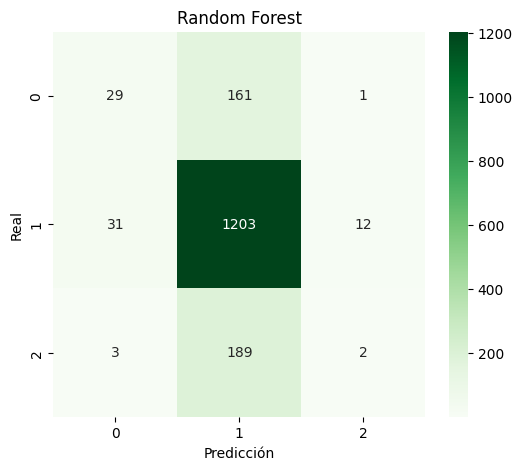

In [69]:
cm = confusion_matrix(
    y_test,
    pred_rf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicción")
plt.ylabel("Real")

plt.title("Random Forest")

plt.show()

In [70]:
importancias_rf = pd.DataFrame({

    "Variable": X_train_encoded.columns,

    "Importancia": modelo_rf.feature_importances_

})

importancias_rf = importancias_rf.sort_values(
    "Importancia",
    ascending=False
)

display(importancias_rf)

,Variable,Importancia
2,KILOMETRO,0.148825
11,DIA,0.120114
4,HORA_NUM,0.096064
1,CODIGO_VÍA,0.091980
0,DEPARTAMENTO,0.079804
3,MODALIDAD,0.073265
12,DIA_SEMANA,0.072306
10,MES,0.064942
5,TEMP,0.043506
6,HR,0.039442


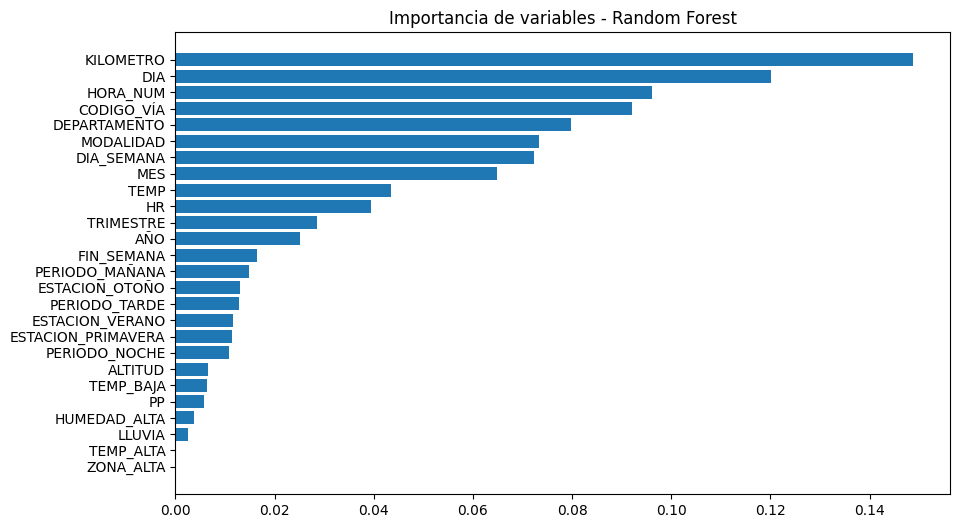

In [71]:
plt.figure(figsize=(10,6))

plt.barh(
    importancias_rf["Variable"],
    importancias_rf["Importancia"]
)

plt.gca().invert_yaxis()

plt.title("Importancia de variables - Random Forest")

plt.show()

XGBoost

In [72]:
modelo_xgb = XGBClassifier(

    objective="multi:softmax",

    num_class=3,

    n_estimators=500,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    eval_metric="mlogloss"

)

# One-hot encode the 'PERIODO' and 'ESTACION' columns
X_train_encoded_xgb = pd.get_dummies(X_train, columns=["PERIODO", "ESTACION"], drop_first=True)
X_test_encoded_xgb = pd.get_dummies(X_test, columns=["PERIODO", "ESTACION"], drop_first=True)

modelo_xgb.fit(
    X_train_encoded_xgb,
    y_train
)

pred_xgb = modelo_xgb.predict(
    X_test_encoded_xgb
)

In [73]:
print("===== XGBOOST =====")

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred_xgb
    )
)

print()

print(
    classification_report(
        y_test,
        pred_xgb
    )
)

===== XGBOOST =====
Accuracy: 0.7559779276517474

              precision    recall  f1-score   support

           0       0.46      0.12      0.19       191
           1       0.77      0.97      0.86      1246
           2       0.20      0.02      0.04       194

    accuracy                           0.76      1631
   macro avg       0.48      0.37      0.36      1631
weighted avg       0.67      0.76      0.68      1631



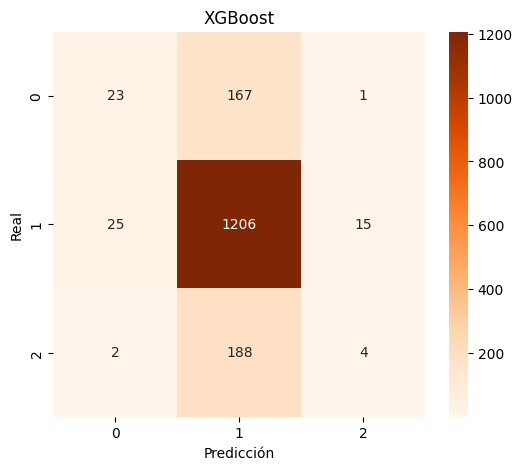

In [74]:
cm = confusion_matrix(
    y_test,
    pred_xgb
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.xlabel("Predicción")
plt.ylabel("Real")

plt.title("XGBoost")

plt.show()

In [75]:
importancias_xgb = pd.DataFrame({

    "Variable": X_train_encoded_xgb.columns,

    "Importancia": modelo_xgb.feature_importances_

})

importancias_xgb = importancias_xgb.sort_values(
    "Importancia",
    ascending=False
)

display(importancias_xgb)

,Variable,Importancia
3,MODALIDAD,0.085707
2,KILOMETRO,0.044663
8,ALTITUD,0.044331
17,TEMP_BAJA,0.044282
22,PERIODO_TARDE,0.043649
0,DEPARTAMENTO,0.043617
1,CODIGO_VÍA,0.043257
11,DIA,0.042947
4,HORA_NUM,0.041966
25,ESTACION_VERANO,0.041820


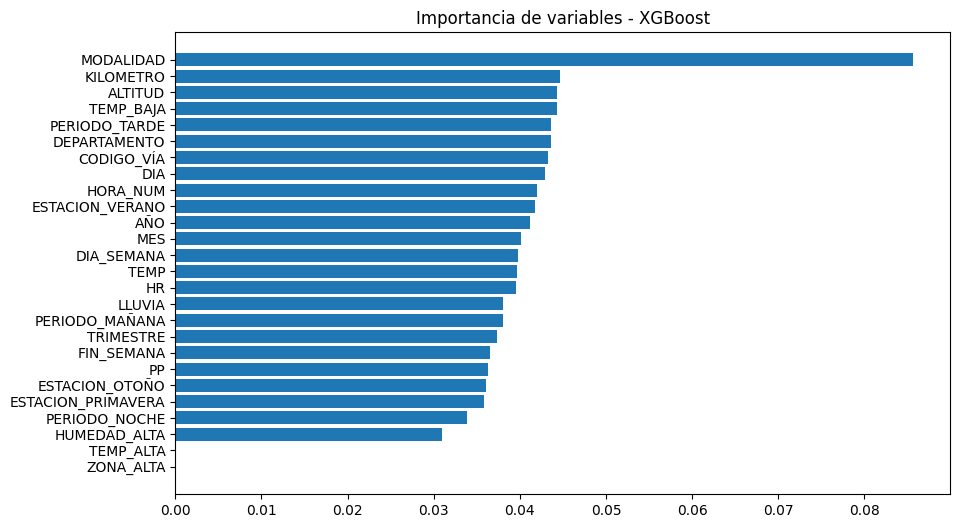

In [76]:
plt.figure(figsize=(10,6))

plt.barh(
    importancias_xgb["Variable"],
    importancias_xgb["Importancia"]
)

plt.gca().invert_yaxis()

plt.title("Importancia de variables - XGBoost")

plt.show()

Optimizacion busqueda automáticamente los mejores parametros

In [77]:
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import time

Random

In [78]:
parametros_rf = {

    "n_estimators":[
        200,
        300,
        500,
        700
    ],

    "max_depth":[
        None,
        10,
        20,
        30
    ],

    "min_samples_split":[
        2,
        5,
        10
    ],

    "min_samples_leaf":[
        1,
        2,
        4
    ],

    "max_features":[
        "sqrt",
        "log2"
    ]

}

In [79]:
inicio = time.time()

# One-hot encode the 'PERIODO' and 'ESTACION' columns for RandomizedSearchCV
X_train_encoded_rf = pd.get_dummies(X_train, columns=["PERIODO", "ESTACION"], drop_first=True)
X_test_encoded_rf = pd.get_dummies(X_test, columns=["PERIODO", "ESTACION"], drop_first=True)

busqueda_rf = RandomizedSearchCV(

    estimator=RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    param_distributions=parametros_rf,

    n_iter=20,

    cv=5,

    scoring="f1_weighted",

    random_state=42,

    n_jobs=-1

)

busqueda_rf.fit(
    X_train_encoded_rf,
    y_train
)

fin = time.time()

tiempo_rf = fin-inicio

In [80]:
print(busqueda_rf.best_params_)

{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30}


In [81]:
mejor_rf = busqueda_rf.best_estimator_

pred_rf_opt = mejor_rf.predict(
    X_test_encoded_rf
)

In [82]:
print(
    classification_report(
        y_test,
        pred_rf_opt
    )
)

              precision    recall  f1-score   support

           0       0.38      0.20      0.27       191
           1       0.78      0.92      0.84      1246
           2       0.23      0.07      0.10       194

    accuracy                           0.73      1631
   macro avg       0.46      0.40      0.40      1631
weighted avg       0.67      0.73      0.69      1631



XGBoost

In [83]:
parametros_xgb={

    "n_estimators":[
        200,
        300,
        500,
        700
    ],

    "max_depth":[
        3,
        5,
        7,
        9
    ],

    "learning_rate":[
        0.01,
        0.05,
        0.1,
        0.2
    ],

    "subsample":[
        0.7,
        0.8,
        1
    ],

    "colsample_bytree":[
        0.7,
        0.8,
        1
    ]

}

In [84]:
inicio=time.time()

busqueda_xgb=RandomizedSearchCV(

    estimator=XGBClassifier(

        objective="multi:softmax",

        num_class=3,

        eval_metric="mlogloss",

        random_state=42

    ),

    param_distributions=parametros_xgb,

    n_iter=20,

    cv=5,

    scoring="f1_weighted",

    random_state=42,

    n_jobs=-1

)

busqueda_xgb.fit(
    X_train_encoded_xgb,
    y_train
)

fin=time.time()

tiempo_xgb=fin-inicio

In [85]:
print(
    busqueda_xgb.best_params_
)

{'subsample': 1, 'n_estimators': 700, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 0.7}


In [86]:
mejor_xgb=busqueda_xgb.best_estimator_

pred_xgb_opt=mejor_xgb.predict(
    X_test_encoded_xgb
)

In [87]:
print(
    classification_report(
        y_test,
        pred_xgb_opt
    )
)

              precision    recall  f1-score   support

           0       0.33      0.13      0.18       191
           1       0.78      0.93      0.85      1246
           2       0.22      0.07      0.11       194

    accuracy                           0.73      1631
   macro avg       0.44      0.38      0.38      1631
weighted avg       0.66      0.73      0.68      1631



**Comparacion**

In [88]:
resultados=[]

In [89]:
def evaluar_modelo(

    nombre,

    modelo,

    X_test,

    y_test,

    tiempo

):

    pred=modelo.predict(
        X_test
    )

    resultados.append({

        "Modelo":nombre,

        "Accuracy":accuracy_score(
            y_test,
            pred
        ),

        "Precision":precision_score(
            y_test,
            pred,
            average="weighted"
        ),

        "Recall":recall_score(
            y_test,
            pred,
            average="weighted"
        ),

        "F1":f1_score(
            y_test,
            pred,
            average="weighted"
        ),

        "Tiempo(s)":round(
            tiempo,
            2
        )

    })

In [90]:
evaluar_modelo(
    "Decision Tree",
    modelo_dt,
    X_test_processed,
    y_test,
    0
)

evaluar_modelo(
    "Random Forest",
    modelo_rf,
    X_test_encoded,
    y_test,
    0
)

evaluar_modelo(
    "XGBoost",
    modelo_xgb,
    X_test_encoded_xgb,
    y_test,
    0
)

evaluar_modelo(
    "RF Optimizado",
    mejor_rf,
    X_test_encoded_rf,
    y_test,
    tiempo_rf
)

evaluar_modelo(
    "XGB Optimizado",
    mejor_xgb,
    X_test_encoded_xgb,
    y_test,
    tiempo_xgb
)

In [91]:
tabla_resultados = pd.DataFrame(
    resultados
)

tabla_resultados = tabla_resultados.sort_values(
    "F1",
    ascending=False
)

tabla_resultados.reset_index(
    drop=True,
    inplace=True
)

tabla_resultados

,Modelo,Accuracy,Precision,Recall,F1,Tiempo(s)
0,RF Optimizado,0.733292,0.665593,0.733292,0.686715,272.08
1,Random Forest,0.756591,0.661543,0.756591,0.685702,0.00
2,XGBoost,0.755978,0.667870,0.755978,0.683245,0.00
3,XGB Optimizado,0.733906,0.657303,0.733906,0.680521,202.72
4,Decision Tree,0.391171,0.640771,0.391171,0.452142,0.00


Validacion Cruzada

In [92]:
from sklearn.model_selection import StratifiedKFold

from sklearn.model_selection import cross_validate

In [93]:
cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)

In [94]:
mejor_rf

RandomForestClassifier(class_weight='balanced', max_depth=30,
                       min_samples_leaf=2, min_samples_split=10,
                       n_estimators=300, random_state=42)

In [95]:
metricas = [

    "accuracy",

    "precision_weighted",

    "recall_weighted",

    "f1_weighted"

]

# One-hot encode the 'PERIODO' and 'ESTACION' columns for cross-validation
X_encoded_cv = pd.get_dummies(X, columns=["PERIODO", "ESTACION"], drop_first=True)

resultado_cv = cross_validate(

    mejor_rf,

    X_encoded_cv,

    y,

    cv=cv,

    scoring=metricas,

    n_jobs=-1

)

In [96]:
print("Accuracy:",resultado_cv["test_accuracy"].mean())

print("Precision:",resultado_cv["test_precision_weighted"].mean())

print("Recall:",resultado_cv["test_recall_weighted"].mean())

print("F1:",resultado_cv["test_f1_weighted"].mean())

Accuracy: 0.7339055793991417
Precision: 0.6527896554641699
Recall: 0.7339055793991417
F1: 0.6803732892533809


In [97]:
print(

    "Accuracy ±",

    resultado_cv["test_accuracy"].std()

)

Accuracy ± 0.007054886505771915


In [98]:
tabla_cv = pd.DataFrame({

    "Métrica":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1"

    ],

    "Promedio":[

        resultado_cv["test_accuracy"].mean(),

        resultado_cv["test_precision_weighted"].mean(),

        resultado_cv["test_recall_weighted"].mean(),

        resultado_cv["test_f1_weighted"].mean()

    ],

    "Desviación":[

        resultado_cv["test_accuracy"].std(),

        resultado_cv["test_precision_weighted"].std(),

        resultado_cv["test_recall_weighted"].std(),

        resultado_cv["test_f1_weighted"].std()

    ]

})

tabla_cv

,Métrica,Promedio,Desviación
0,Accuracy,0.733906,0.007055
1,Precision,0.652790,0.011751
2,Recall,0.733906,0.007055
3,F1,0.680373,0.007943


Distribución de la variable objetivo

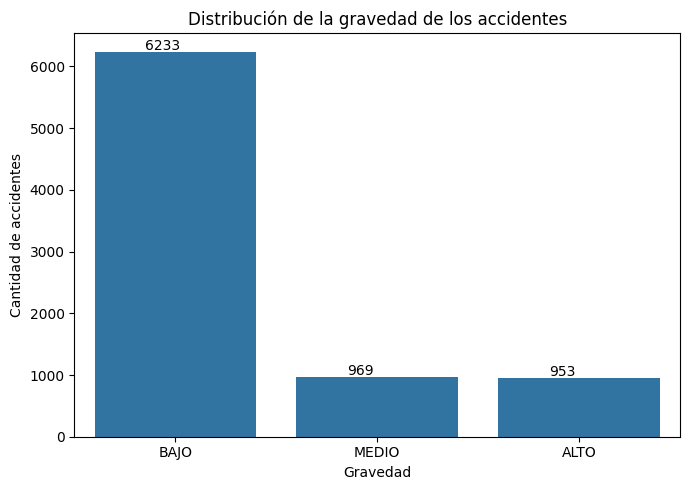

In [99]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="GRAVEDAD",
    data=dataset_modelo,
    order=["BAJO","MEDIO","ALTO"]
)

plt.title("Distribución de la gravedad de los accidentes")
plt.xlabel("Gravedad")
plt.ylabel("Cantidad de accidentes")

for p in plt.gca().patches:
    plt.text(
        p.get_x()+0.25,
        p.get_height()+30,
        int(p.get_height())
    )

plt.tight_layout()
plt.show()

Importancia de variables

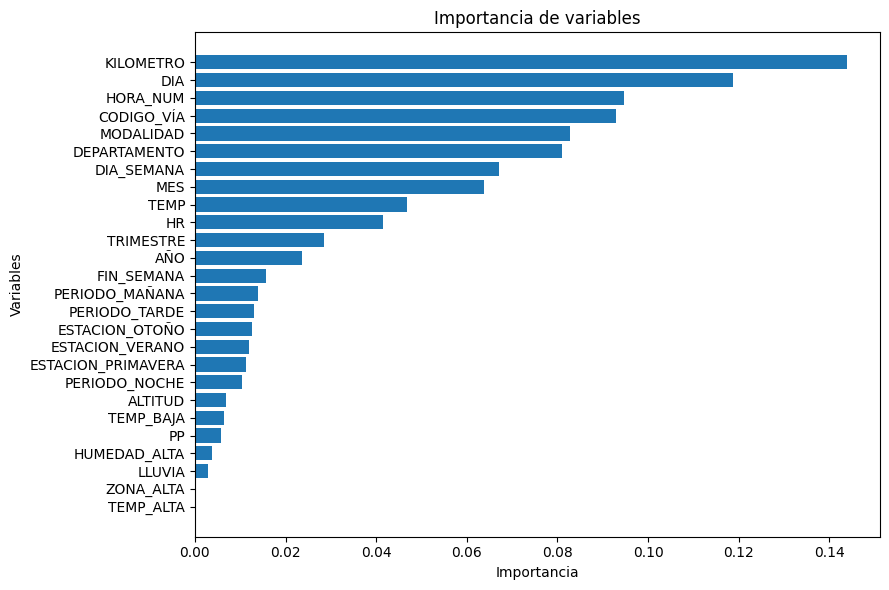

In [100]:
importancias = pd.DataFrame({
    "Variable": X_encoded_cv.columns,
    "Importancia": mejor_rf.feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=True
)

plt.figure(figsize=(9,6))

plt.barh(
    importancias["Variable"],
    importancias["Importancia"]
)

plt.title("Importancia de variables")
plt.xlabel("Importancia")
plt.ylabel("Variables")

plt.tight_layout()
plt.show()

Matriz de confusión

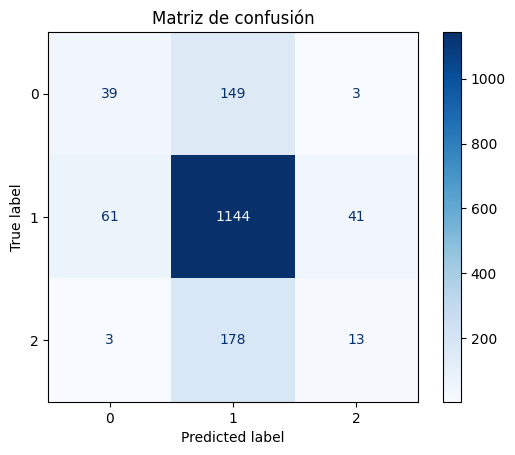

In [101]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(

    mejor_rf,

    X_test_encoded_rf,

    y_test,

    cmap="Blues"

)

plt.title("Matriz de confusión")

plt.show()

Comparación de modelos

In [102]:
tabla_modelos = pd.DataFrame({

    "Modelo":[
        "Decision Tree",
        "Random Forest",
        "RF Optimizado",
        "XGBoost",
        "XGB Optimizado"
    ],

    "Accuracy":[
        0.416309,
        0.733906,
        0.748620,
        0.755365,
        0.762109
    ],

    "Precision":[
        0.665094,
        0.648012,
        0.660562,
        0.663260,
        0.646649
    ],

    "Recall":[
        0.416309,
        0.733906,
        0.748620,
        0.755365,
        0.762109
    ],

    "F1":[
        0.475947,
        0.676216,
        0.683032,
        0.681621,
        0.678863
    ]

})

tabla_modelos

,Modelo,Accuracy,Precision,Recall,F1
0,Decision Tree,0.416309,0.665094,0.416309,0.475947
1,Random Forest,0.733906,0.648012,0.733906,0.676216
2,RF Optimizado,0.748620,0.660562,0.748620,0.683032
3,XGBoost,0.755365,0.663260,0.755365,0.681621
4,XGB Optimizado,0.762109,0.646649,0.762109,0.678863


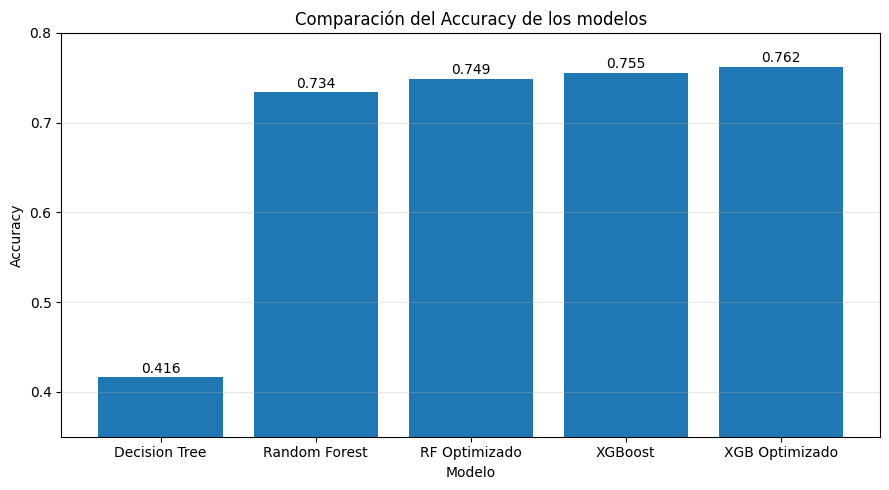

In [103]:
plt.figure(figsize=(9,5))

plt.bar(
    tabla_modelos["Modelo"],
    tabla_modelos["Accuracy"]
)

plt.title("Comparación del Accuracy de los modelos")
plt.xlabel("Modelo")
plt.ylabel("Accuracy")

plt.ylim(0.35,0.80)

for i, valor in enumerate(tabla_modelos["Accuracy"]):
    plt.text(
        i,
        valor+0.005,
        f"{valor:.3f}",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [104]:
tabla_modelos

,Modelo,Accuracy,Precision,Recall,F1
0,Decision Tree,0.416309,0.665094,0.416309,0.475947
1,Random Forest,0.733906,0.648012,0.733906,0.676216
2,RF Optimizado,0.748620,0.660562,0.748620,0.683032
3,XGBoost,0.755365,0.663260,0.755365,0.681621
4,XGB Optimizado,0.762109,0.646649,0.762109,0.678863


In [105]:
tabla_cv.round(4)

,Métrica,Promedio,Desviación
0,Accuracy,0.7339,0.0071
1,Precision,0.6528,0.0118
2,Recall,0.7339,0.0071
3,F1,0.6804,0.0079


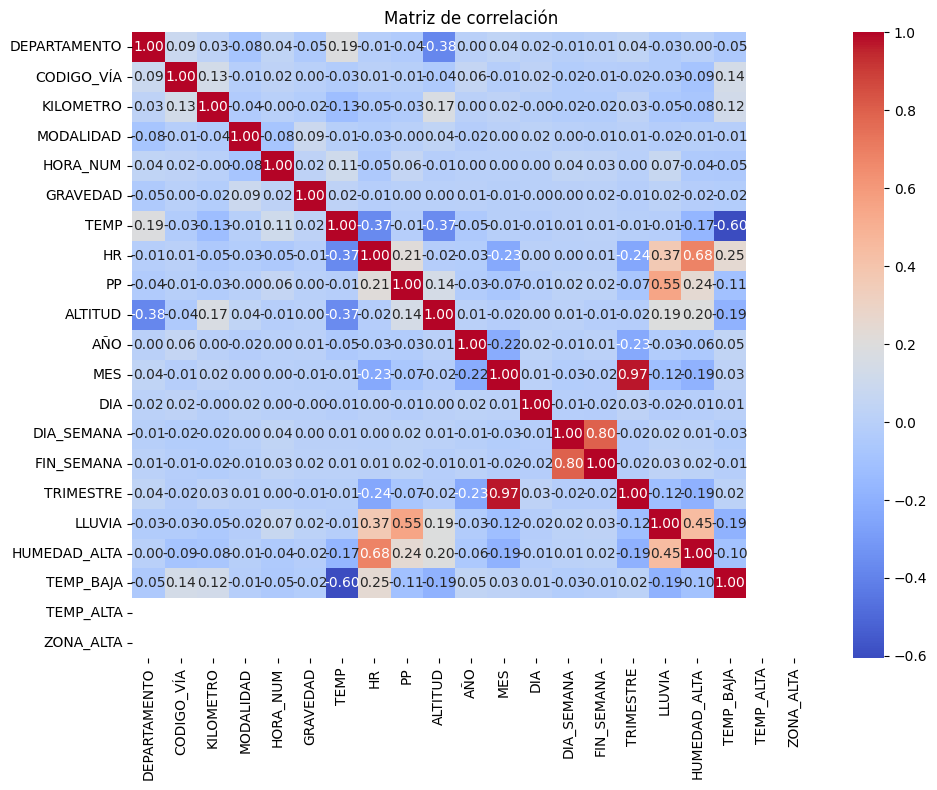

In [106]:
plt.figure(figsize=(10,8))

sns.heatmap(

    dataset_ml.select_dtypes(include=np.number).corr(),

    annot=True,

    cmap="coolwarm",

    fmt=".2f"

)

plt.title("Matriz de correlación")

plt.tight_layout()

plt.show()

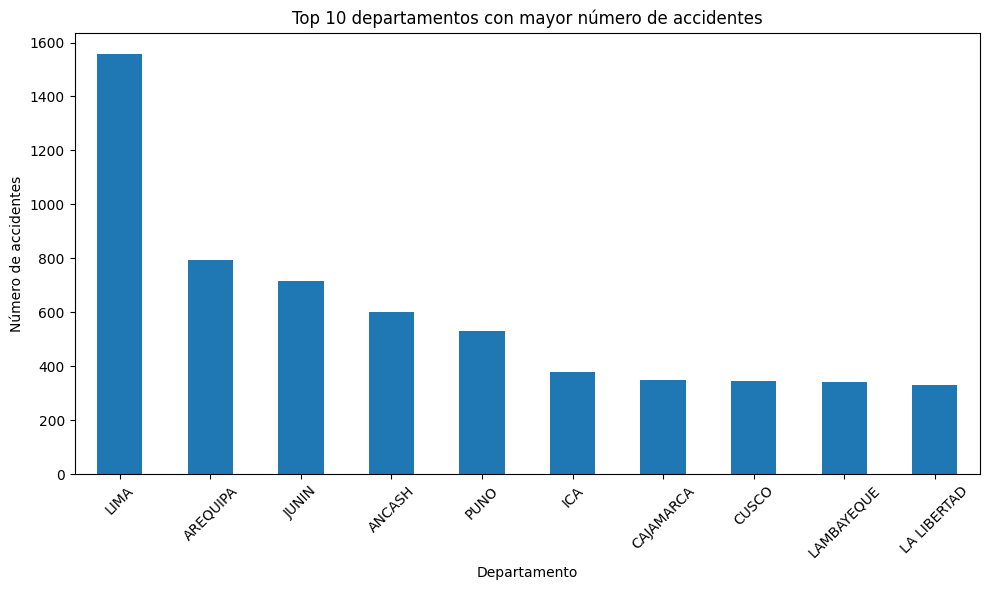

In [107]:
plt.figure(figsize=(10,6))

(
    dataset_modelo["DEPARTAMENTO"]
    .value_counts()
    .head(10)
    .plot(kind="bar")
)

plt.title("Top 10 departamentos con mayor número de accidentes")
plt.xlabel("Departamento")
plt.ylabel("Número de accidentes")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()